# Project Brief 

In this project, I want to predict the total number of bike rentals in one hour (cnt).
The dataset contains hourly data from 2011 to 2012.
Each row represents one hour.

The data includes information like hour of the day, season, weekday, temperature, humidity, windspeed, and weather condition.

My goal is to build a regression model that can estimate how many bikes will be rented in a given hour using this information.

This problem is useful because it can help manage bike availability and avoid shortages or too many unused bikes.

I will first build simple baseline models, then try more advanced models.

I will measure performance using MAE and RMSE.

A good result means my model performs better than the baseline and works well on future data.

## 5 Features I Expect to Matter

1. hr (hour of the day)
I expect this to matter because people rent bikes more during rush hours like morning and evening.

2. temp (temperature)
When the weather is warm, more people are likely to rent bikes. Very cold weather may reduce rentals.

3. weathersit (weather condition)
Bad weather like rain or snow will probably reduce the number of bike rentals.

4. workingday
On working days, people may use bikes to go to work, so rentals might be higher than weekends.

5. season
Different seasons may affect bike usage. For example, winter might have fewer rentals than summer.

## Questions
#### 1. What is a prediction error that would be acceptable in the real world here?

An acceptable error would be small enough that the bike stations can still manage supply correctly. For example, being wrong by 10–20 bikes per hour might be acceptable, but being wrong by 100 bikes would cause problems. The acceptable error also depends on how many bikes are usually rented in that hour.

### 2. What would make your model unusable or misleading?

The model would be unusable if it makes very large errors during hours when many bikes are renteds. It would also be misleading if it performs well on training data but fails on future/unseen data.

# Load data and column understanding

In [58]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('C:\\Users\\Mr.Zabit\\Documents\\ml_projects\\bike_rental_project\\data\\raw\\hour.csv')
df.head(3)



,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


In [3]:
df.shape

(17379, 17)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [5]:
df.dtypes

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [6]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [7]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### Questions 
• Which columns are categorical vs numeric?

• Which columns are IDs or dates? Which should (or should not) be used directly?

| Column     | Meaning                                       | Type        | Use as Predictor? |
| ---------- | --------------------------------------------- | ----------- | ----------------- |
| instant    | Row ID                                        | ID          | No                |
| dteday     | Date of record                                | date        | No                |
| season     | Season (1=Spring, 2=Summer, 3=Fall, 4=Winter) | categorical | Yes               |
| yr         | Year (0=2011, 1=2012)                         | categorical | Yes               |
| mnth       | Month (1–12)                                  | categorical | Yes               |
| hr         | Hour of day (0–23)                            | categorical | Yes               |
| holiday    | Whether it is a holiday (0/1)                 | categorical | Yes               |
| weekday    | Day of week (0=Sunday … 6=Saturday)           | categorical | Yes               |
| workingday | Whether it is a working day (0/1)             | categorical | Yes               |
| weathersit | Weather situation (1–4)                       | categorical | Yes               |
| temp       | Normalized temperature                        | numeric     | Yes               |
| atemp      | Normalized “feels like” temperature           | numeric     | Yes               |
| hum        | Humidity                                      | numeric     | Yes               |
| windspeed  | Windspeed                                     | numeric     | Yes               |
| casual     | Casual rentals                                | numeric     | No                |
| registered | Registered rentals                            | numeric     | No                |
| cnt        | Total rentals (target)                        | numeric     | Target            |




# Exploratory Data Analysis(EDA) 


### Hypothesis:

I expect cnt to be right-skewed — most hours have moderate rentals, few hours have very high rentals.

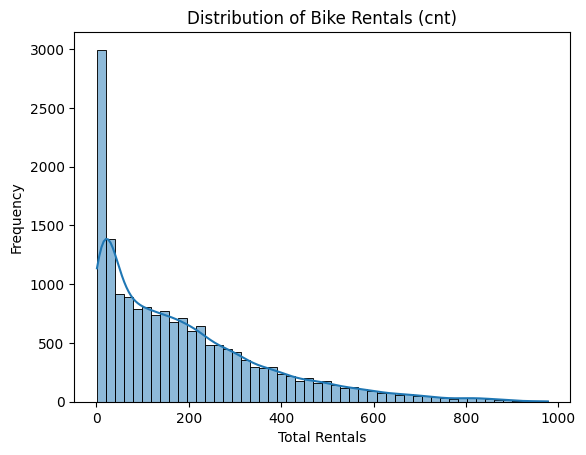

In [8]:
sns.histplot(df['cnt'], bins=50, kde=True)
plt.title('Distribution of Bike Rentals (cnt)')
plt.xlabel('Total Rentals')
plt.ylabel('Frequency')
plt.show()


### Hypothesis

Rush hours (7–9 AM, 17–19 PM) → higher rentals

Weekends → lower rentals for commuting

Bad weather → fewer rentals

Winter → fewer rentals than summer

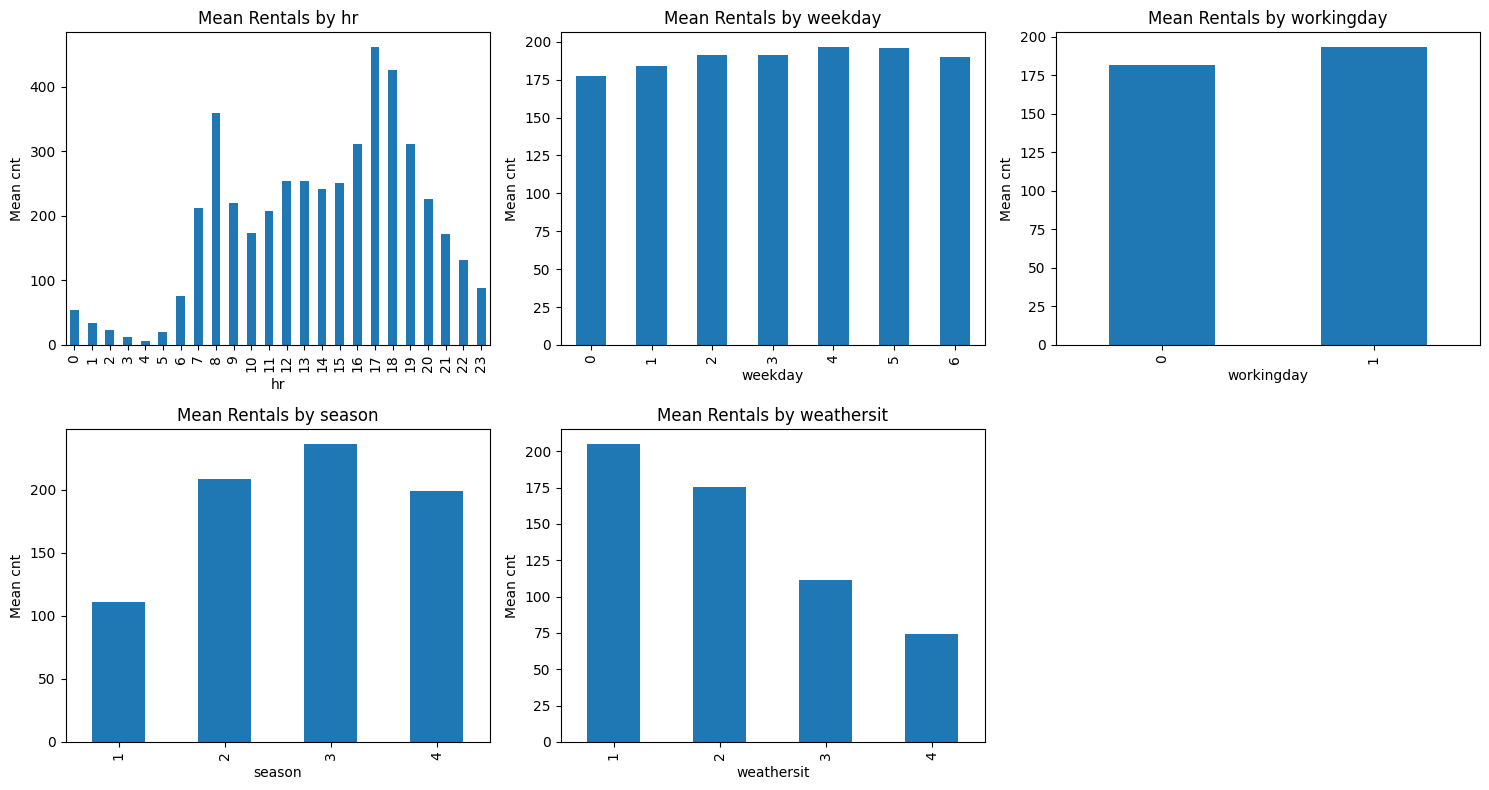

In [9]:
cols = ['hr', 'weekday', 'workingday', 'season', 'weathersit']
n_cols = 3  # number of plots per row
n_rows = (len(cols) + n_cols - 1) // n_cols  # compute number of rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten()  # flatten to 1D array for easy iteration

for i, col in enumerate(cols):
    df.groupby(col)['cnt'].mean().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Mean Rentals by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Mean cnt')

# Remove any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Hypothesis

Higher temperature → more rentals

High humidity → fewer rentals

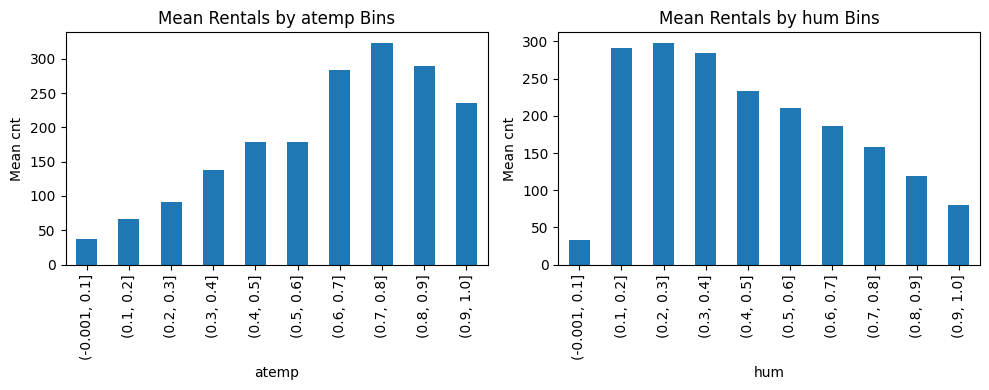

In [10]:
cols = ["atemp", "hum"]
n_cols = 2
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(cols):
    df[col + '_bin'] = pd.cut(df[col], bins=10)
    df.groupby(col + '_bin')['cnt'].mean().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Mean Rentals by {col} Bins')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Mean cnt')

plt.tight_layout()
plt.show()


### 1What 3 patterns are strongest?

Rush hour effect (hr)
The strongest pattern is that rentals increase during morning (7–9) and evening (17–19) hours.

Working day vs non-working day
Rentals are higher on working days compared to non-working days. This suggests many people use bikes for going to work.

Weather / Temperature effect
Rentals increase when temperature is moderate or warm, and decrease during bad weather conditions.

### Do you see any interactions?

Yes, I see some interactions.

One interaction is between hour and workingday. During the working day the rental increases compared non-workingdays, this shows cnt depends on workingdays.

# Evaluation setup

In [11]:
df['dteday'] = pd.to_datetime(df['dteday'])


In [12]:
df['dteday'].dtype


dtype('<M8[us]')

In [13]:
df['dteday'].min(), df['dteday'].max()


(Timestamp('2011-01-01 00:00:00'), Timestamp('2012-12-31 00:00:00'))

In [27]:
"""I split the dataset based on date instead of using a random split. 
The training set contains data before July 2012, and the test set contains data from July 2012 onward. 
This approach is more realistic because in real life we train on past data and predict future data."""

split_date = '2012-07-01'

train = df[df['dteday'] < split_date]
test  = df[df['dteday'] >= split_date]

print(test.shape)


(4376, 19)


In [21]:
def MAE(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def RMSE(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def r2_score(y_true, y_pred):
    ss_error = np.sum((y_true - y_pred) ** 2)
    ss_total = np.sum((y_true - (np.mean(y_true))) ** 2)
    return 1 - (ss_error / ss_total)


### 1. Why does RMSE punish big misses more than MAE?

RMSE squares the errors before averaging.
Squaring makes big errors much bigger.

### 2. How would a random split overestimate performance here?

If we use random split, the model trains on some future data.

That means it already learns future patterns.

So when predicting the test set, it is easier.

This makes the performance look better than real life.

# Baseline Model

In [52]:
# Training mean
train_mean = train['cnt'].mean()

# Predict same value for all test rows
y_pred_A = [train_mean] * len(test)

y_test = test['cnt'].values

# Evaluate
print("Baseline A")
print("MAE:", round(MAE(y_test, y_pred_A), 2))
print("RMSE:", round(RMSE(y_test, y_pred_A), 2))
print("R2:", round(r2_score(y_test, y_pred_A), 2))

Baseline A
MAE: 177.39
RMSE: 236.06
R2: -0.15


In [53]:
# Calculate mean cnt per hour using training data
hour_means = train.groupby('hr')['cnt'].mean()


# Map test hours to these means
y_pred_B = test['hr'].map(hour_means).values

# Evaluate
print("Baseline B")
print("MAE:", round(MAE(y_test, y_pred_B), 2))
print("RMSE:", round(RMSE(y_test, y_pred_B), 2))
print("R2:", round(r2_score(y_test, y_pred_B), 2))

Baseline B
MAE: 118.49
RMSE: 172.06
R2: 0.39


## Questions
1. How much does the hour-based baseline improve over the mean baseline?

| Model    | MAE | RMSE | R²   |
| -------- | --- | ---- | ---- |
| Mean (A) | 177.39 | 236.06  | -0.15 |
| Hour (B) | 118.49  | 172.06  | 0.39 |


The hour-based reduces the MAE by about 59 bikes and RMSE by about 64 bikes compared to the mean baseline.

R² improves from -0.15 to 0.39, which is large improvement

2. What does that tell you about how much signal is in 'hour of day'?

Because the hour-based model performs much better, it means that hour of day is very important for predicting bike rentals. It contains strong signal.


Baseline A predicts the overall training mean every time.

Baseline B predicts the average number of rentals for each hour.

Baseline B performs better because hour strongly affects bike rentals.


# Linear Regression

In [65]:
# Define features
categorical_features = [
    'season', 'yr', 'mnth', 'hr',
    'holiday', 'weekday', 'workingday', 'weathersit'
]

numeric_features = ['temp', 'atemp', 'hum', 'windspeed']

X_train = train[categorical_features + numeric_features]
y_train = train['cnt']

X_test = test[categorical_features + numeric_features]
y_test = test['cnt']

In [68]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

# Full pipeline
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regression', LinearRegression())
])

In [69]:
# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
print("MAE:", MAE(y_test.values, y_pred))
print("RMSE:", RMSE(y_test.values, y_pred))
print("R2:", r2_score(y_test.values, y_pred))

MAE: 100.90106335513255
RMSE: 135.11641735307256
R2: 0.6217424130268183


In [73]:
# Get feature names after one-hot encoding
feature_names = model.named_steps['preprocessing'].get_feature_names_out()

# Get coefficients
coefficients = model.named_steps['regression'].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

# Top positive
print("Top positive coefficients:")
print(coef_df.sort_values(by='coefficient', ascending=False).head(10))

# Top negative
print("\nTop negative coefficients:")
print(coef_df.sort_values(by='coefficient').head(10))


Top positive coefficients:
       feature  coefficient
31  cat__hr_17   335.251191
32  cat__hr_18   308.986357
22   cat__hr_8   275.451925
33  cat__hr_19   211.956735
30  cat__hr_16   196.593564
26  cat__hr_12   153.216141
27  cat__hr_13   150.580955
21   cat__hr_7   150.062900
23   cat__hr_9   147.166093
29  cat__hr_15   143.427942

Top negative coefficients:
              feature  coefficient
51           num__hum   -70.936211
47  cat__weathersit_3   -64.636297
48  cat__weathersit_4   -58.085137
52     num__windspeed   -35.584075
18          cat__hr_4   -34.624024
17          cat__hr_3   -31.813185
16          cat__hr_2   -22.201391
19          cat__hr_5   -19.912826
15          cat__hr_1   -14.733500
38     cat__holiday_1   -13.501357


## Questions

1. What is the linear model assuming about relationships between features and cnt?

The linear model thinks that each thing we use to predict (like hour, weather, or temperature) adds or reduces a fixed number of bike rentals.

2. Which coefficients match your intuition? Which do not? 

Hours increase rentals, bad weather and high humidity decrease rentals — these coefficients match intuition.